In [12]:
import gymnasium as gym
import pandas as pd
from collections import deque
import highway_env
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from tqdm import tqdm
from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from aggressive_config import SHARED_CORE_ENV_ID, AGGRESSIVE_CONFIG
from shared_core_config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG
import imageio
from IPython.display import Image

## Useful functions

In [13]:
def make_env_hard(render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    env.unwrapped.configure(AGGRESSIVE_CONFIG)
    env.reset()
    env = Monitor(env) 
    return env

def make_env(render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    env.unwrapped.configure(SHARED_CORE_CONFIG)
    env.reset()
    env = Monitor(env) 
    return env

In [14]:
ACTION_NAMES = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}
N_ACTIONS = len(ACTION_NAMES)

def evaluate_agent(agent, num_episodes=50, seeds=[3, 333, 3333]):
    """
    Evaluates an agent on multiple seeds.
    Returns a list of (seed, metrics_dict, episode_rewards) tuples.

    New in metrics_dict:
      - episode_mean_speeds  : list of length num_episodes — mean ego speed per episode
      - episode_action_counts: list of length num_episodes — np.array of shape (N_ACTIONS,)
                               counting how many times each action was chosen that episode
    These two lists are what you pass directly to the plotting functions.
    """
    print(f"Starting evaluation: {num_episodes} episodes per seed.")
    all_seed_results = []

    for seed in seeds:
        env = make_env()
        episode_rewards  = []
        episode_lengths  = []
        episode_crashed  = []
        episode_mean_speeds   = []  
        episode_action_counts = []   

        for episode in tqdm(range(num_episodes), desc=f"Evaluating Seed {seed}"):
            obs, info = env.reset(seed=seed + episode)
            done         = False
            total_reward = 0
            steps        = 0
            step_speeds  = []                    
            step_actions = []                   

            while not done:
                if hasattr(agent, "predict"):
                    action, _states = agent.predict(obs, deterministic=True)
                else:
                    q_values = agent.get_q(obs)
                    action   = np.argmax(q_values)

                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += reward
                steps        += 1
                done = terminated or truncated

                step_speeds.append(info["speed"]) 
                step_actions.append(int(action))

            episode_rewards.append(total_reward)
            episode_lengths.append(steps)
            episode_crashed.append(bool(terminated))

            # NEW — aggregate speed and actions for this episode
            episode_mean_speeds.append(np.mean(step_speeds))

            action_counts = np.zeros(N_ACTIONS, dtype=int)
            for a in step_actions:
                action_counts[a] += 1
            episode_action_counts.append(action_counts)

        env.close()

        # Existing metrics — unchanged
        mean_reward   = np.mean(episode_rewards)
        std_reward    = np.std(episode_rewards)
        min_reward    = np.min(episode_rewards)
        max_reward    = np.max(episode_rewards)
        mean_steps    = np.mean(episode_lengths)
        std_steps     = np.std(episode_lengths)
        min_steps     = np.min(episode_lengths)
        max_steps     = np.max(episode_lengths)
        n_crashes     = sum(episode_crashed)
        crash_rate    = n_crashes / num_episodes * 100
        survival_rate = 100 - crash_rate

        # NEW — aggregate speed and action metrics across all episodes of this seed
        mean_speed = np.mean(episode_mean_speeds)
        # mean_action_counts[a] = average number of times action a was chosen per episode
        mean_action_counts = np.mean(episode_action_counts, axis=0)  # shape (N_ACTIONS,)

        metrics = {
            "mean_reward":    mean_reward,
            "std_reward":     std_reward,
            "min_reward":     min_reward,
            "max_reward":     max_reward,
            "mean_steps":     mean_steps,
            "std_steps":      std_steps,
            "min_steps":      min_steps,
            "max_steps":      max_steps,
            "n_crashes":      n_crashes,
            "crash_rate":     crash_rate,
            "survival_rate":  survival_rate,
            # NEW
            "mean_speed":          mean_speed,
            "mean_action_counts":  mean_action_counts,  
            "episode_mean_speeds": episode_mean_speeds,  
            "episode_action_counts": episode_action_counts,  
        }

        print(f"\n{'='*50}")
        print(f"Seed {seed} — {num_episodes} episodes")
        print(f"{'='*50}")
        print(f"  Reward     : {mean_reward:6.2f} ± {std_reward:.2f}  "
              f"[min: {min_reward:.2f}, max: {max_reward:.2f}]")
        print(f"  Steps      : {mean_steps:6.1f} ± {std_steps:.1f}  "
              f"[min: {min_steps}, max: {max_steps}]")
        print(f"  Crashes    : {n_crashes}/{num_episodes} "
              f"({crash_rate:.1f}% crash rate, {survival_rate:.1f}% survival)")
        # NEW
        print(f"  Mean speed : {mean_speed:.2f} m/s")
        print(f"  Action breakdown (mean counts/episode):")
        for a, name in ACTION_NAMES.items():
            print(f"    {name:<12}: {mean_action_counts[a]:5.1f} steps")
        print()

        all_seed_results.append((seed, metrics, episode_rewards))

    # Aggregate across seeds — unchanged block + new lines
    all_means     = [m["mean_reward"]   for _, m, _ in all_seed_results]
    all_survivals = [m["survival_rate"] for _, m, _ in all_seed_results]
    all_steps     = [m["mean_steps"]    for _, m, _ in all_seed_results]
    all_speeds    = [m["mean_speed"]    for _, m, _ in all_seed_results] 

    print(f"\n{'='*50}")
    print(f"OVERALL ({len(seeds)} seeds)")
    print(f"{'='*50}")
    print(f"  Mean reward    : {np.mean(all_means):.2f} ± {np.std(all_means):.2f}  (std is across seeds)")
    print(f"  Survival rate  : {np.mean(all_survivals):.1f}%")
    print(f"  Mean steps     : {np.mean(all_steps):.1f}")
    print(f"  Mean speed     : {np.mean(all_speeds):.2f} m/s") 

    return all_seed_results

In [15]:
def plot_training_curves(episode_rewards, episode_losses, episode_lengths=None, epsilon_history=None):
    has_lengths = episode_lengths is not None
    has_epsilon = epsilon_history is not None

    n_plots = 2 + has_lengths + has_epsilon
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    ax_idx = 0

    # Reward curve
    ax = axes[ax_idx]; ax_idx += 1
    ax.plot(episode_rewards, alpha=0.3, color='blue', label='Raw reward')
    if len(episode_rewards) >= 20:
        rolling_mean = np.convolve(episode_rewards, np.ones(20)/20, mode='valid')
        rolling_std  = np.array([np.std(episode_rewards[i:i+20]) for i in range(len(episode_rewards)-19)])
        x = range(19, len(episode_rewards))
        ax.plot(x, rolling_mean, color='blue', linewidth=2, label='20-ep Moving Avg')
        ax.fill_between(x, rolling_mean - rolling_std, rolling_mean + rolling_std,
                        alpha=0.2, color='blue', label='\u00b11 std')
    ax.set_title("Training curve: Episode rewards")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total reward")
    ax.legend()

    # Loss curve
    ax = axes[ax_idx]; ax_idx += 1
    ax.plot(episode_losses, color='orange', alpha=0.8)
    ax.set_title("Training curve: Mean loss per episode")
    ax.set_xlabel("Episode")
    ax.set_ylabel("MSE loss")

    # Steps per episode
    if has_lengths:
        ax = axes[ax_idx]; ax_idx += 1
        ax.plot(episode_lengths, alpha=0.3, color='green', label='Steps')
        if len(episode_lengths) >= 20:
            rolling_len = np.convolve(episode_lengths, np.ones(20)/20, mode='valid')
            ax.plot(range(19, len(episode_lengths)), rolling_len,
                    color='green', linewidth=2, label='20-ep Moving Avg')
        ax.set_title("Steps per episode (survival time)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Steps")
        ax.legend()

    # Epsilon decay
    if has_epsilon:
        ax = axes[ax_idx]; ax_idx += 1
        ax.plot(epsilon_history, color='red', linewidth=1.5)
        ax.set_title("Epsilon (exploration rate)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Epsilon")
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

In [16]:
def train_agent(agent, env, n_episodes=500):
    episode_rewards, episode_losses, episode_lengths, epsilon_history = [], [], [], []
    episode_mean_q, episode_true_returns = [], []

    for episode in tqdm(range(n_episodes), desc="Training agent"):
        state, _ = env.reset()
        done = False
        total_reward, step_count = 0, 0
        ep_losses, ep_q_values, ep_rewards = [], [], []

        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            result = agent.update(state, action, reward, terminated, truncated, next_state)
            if result[0] != np.inf:
                ep_losses.append(result[0])

            # Compute Q on the ACTUAL current state, not a random batch
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(agent.device)
                q_val = agent.q_net(state_tensor).max(1)[0].item()
            ep_q_values.append(q_val)         
            ep_rewards.append(reward)
            state = next_state
            total_reward += reward
            step_count += 1

        # True discounted return from t=0
        true_return = 0
        for r in reversed(ep_rewards):
            true_return = r + agent.gamma * true_return

        episode_rewards.append(total_reward)
        episode_lengths.append(step_count)
        epsilon_history.append(agent.epsilon)
        episode_true_returns.append(true_return)                         
        episode_mean_q.append(np.mean(ep_q_values) if ep_q_values else 0) 
        episode_losses.append(np.mean(ep_losses) if ep_losses else 0.0)

    return agent, episode_rewards, episode_losses, episode_lengths, epsilon_history, episode_mean_q, episode_true_returns

## Final DQN

In [17]:
import random
from typing import Optional

import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state: np.ndarray, action: int, reward: float, terminated: bool, next_state: np.ndarray) -> None:
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, terminated, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size: int) -> list[tuple[Tensor, Tensor, Tensor, Tensor, Tensor]]:
        return random.choices(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)


class Net(nn.Module):
    def __init__(self, obs_shape: tuple[int, ...], hidden_size: int, n_actions: int):
        super(Net, self).__init__()

        in_features = int(np.prod(obs_shape))
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class HighwayDQN:
    def __init__(self,
                 env: gym.Env,
                 gamma: float,
                 batch_size: int,
                 buffer_capacity: int,
                 update_target_every: int,
                 epsilon_start: float,
                 decrease_epsilon_factor: float,
                 epsilon_min: float,
                 learning_rate: float,
                 model_type: str = "DDQN"):

        self.env = env
        self.action_space = env.action_space
        self.observation_space = env.observation_space
        self.gamma = gamma

        self.batch_size = batch_size
        self.buffer_capacity = buffer_capacity
        self.update_target_every = update_target_every

        self.epsilon_start = epsilon_start
        self.decrease_epsilon_factor = decrease_epsilon_factor
        self.epsilon_min = epsilon_min

        self.learning_rate = learning_rate
        self.device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
        self.model_type = model_type 
        print(f"Initializing DQN on device: {self.device}")

        self.reset()

    def reset(self):
        hidden_size = 256

        obs_shape = self.observation_space.shape
        n_actions = int(self.action_space.n)

        self.buffer = ReplayBuffer(self.buffer_capacity)
        self.q_net = Net(obs_shape, hidden_size, n_actions).to(self.device)
        self.target_net = Net(obs_shape, hidden_size, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.loss_function = nn.MSELoss()
        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)

        self.epsilon = self.epsilon_start
        self.n_steps = 0
        self.n_eps = 0

    def get_q(self, state: np.ndarray) -> np.ndarray:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net(state_tensor)
        return output.cpu().numpy()[0]

    def decrease_epsilon(self):
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_steps / self.decrease_epsilon_factor) )

    def get_action(self, state: np.ndarray, epsilon: Optional[float] = None) -> int:
        if epsilon is None:
            epsilon = self.epsilon

        if np.random.rand() < epsilon:  # type: ignore
            return self.action_space.sample()

        return int(np.argmax(self.get_q(state)))

    def update(self, state: np.ndarray, action: int, reward: float,
            terminated: bool, truncated: bool, next_state: np.ndarray) -> tuple:  # added truncated
        self.buffer.push(state, action, reward, terminated, next_state)
        if len(self.buffer) < self.batch_size:
            self.n_steps += 1
            return np.inf, np.inf  
        
        transitions = self.buffer.sample(self.batch_size)
        states, actions, rewards, terminateds, next_states = zip(*transitions)

        states_t = torch.as_tensor(np.array(states), dtype=torch.float32,  device=self.device)
        actions_t = torch.as_tensor(actions, dtype=torch.int64,    device=self.device).unsqueeze(1)
        rewards_t = torch.as_tensor(rewards, dtype=torch.float32,  device=self.device)
        terminateds_t = torch.as_tensor(terminateds, dtype=torch.float32,  device=self.device)
        next_states_t = torch.as_tensor(np.array(next_states), dtype=torch.float32,  device=self.device)

        values = self.q_net(states_t).gather(1, actions_t)
        with torch.no_grad():
            if self.model_type == "DDQN":
                next_state_actions = self.q_net.forward(next_states_t).argmax(dim=1).unsqueeze(1)
                next_q_values = self.target_net.forward(next_states_t).gather(1, next_state_actions).squeeze(1)
            else:
                next_q_values = self.target_net.forward(next_states_t).max(1)[0]
            targets = rewards_t + self.gamma * next_q_values * (1 - terminateds_t)

        loss = self.loss_function(values, targets.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if not ((self.n_steps + 1) % self.update_target_every):
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.decrease_epsilon()
        self.n_steps += 1

        mean_max_q = self.q_net(states_t).max(1)[0].detach().mean().item()
        return loss.detach().item(), mean_max_q 

    def save(self, filepath: str):
        """Saves the Q-network's weights to a file."""
        torch.save(self.q_net.state_dict(), filepath)

    def load(self, filepath: str):
        """Loads the Q-network's weights from a file."""
        self.q_net.load_state_dict(torch.load(filepath, map_location=self.device))
        self.target_net.load_state_dict(self.q_net.state_dict())

## Train agent on hard config

In [18]:
N_EPISODES = 600

env = make_env_hard()
dqn_agent = HighwayDQN(
        env=env,
        gamma=0.8,
        batch_size=64,
        buffer_capacity=15000,
        update_target_every=50,
        epsilon_start=1.0,
        decrease_epsilon_factor=6000,
        epsilon_min=0.05,
        learning_rate=5e-4,
        model_type="DDQN",
    )

trained_dqn_agent, dqn_rewards, dqn_losses, dqn_lengths, dqn_epsilons, dqn_mean_q, dqn_true_returns = train_agent(dqn_agent, env, n_episodes=N_EPISODES)

Initializing DQN on device: cpu


Training agent: 100%|██████████| 600/600 [1:58:18<00:00, 11.83s/it]  


In [19]:
file_path = "./models/agressive_ddqn_highway.pth"
torch.save(trained_dqn_agent.q_net.state_dict(), file_path)

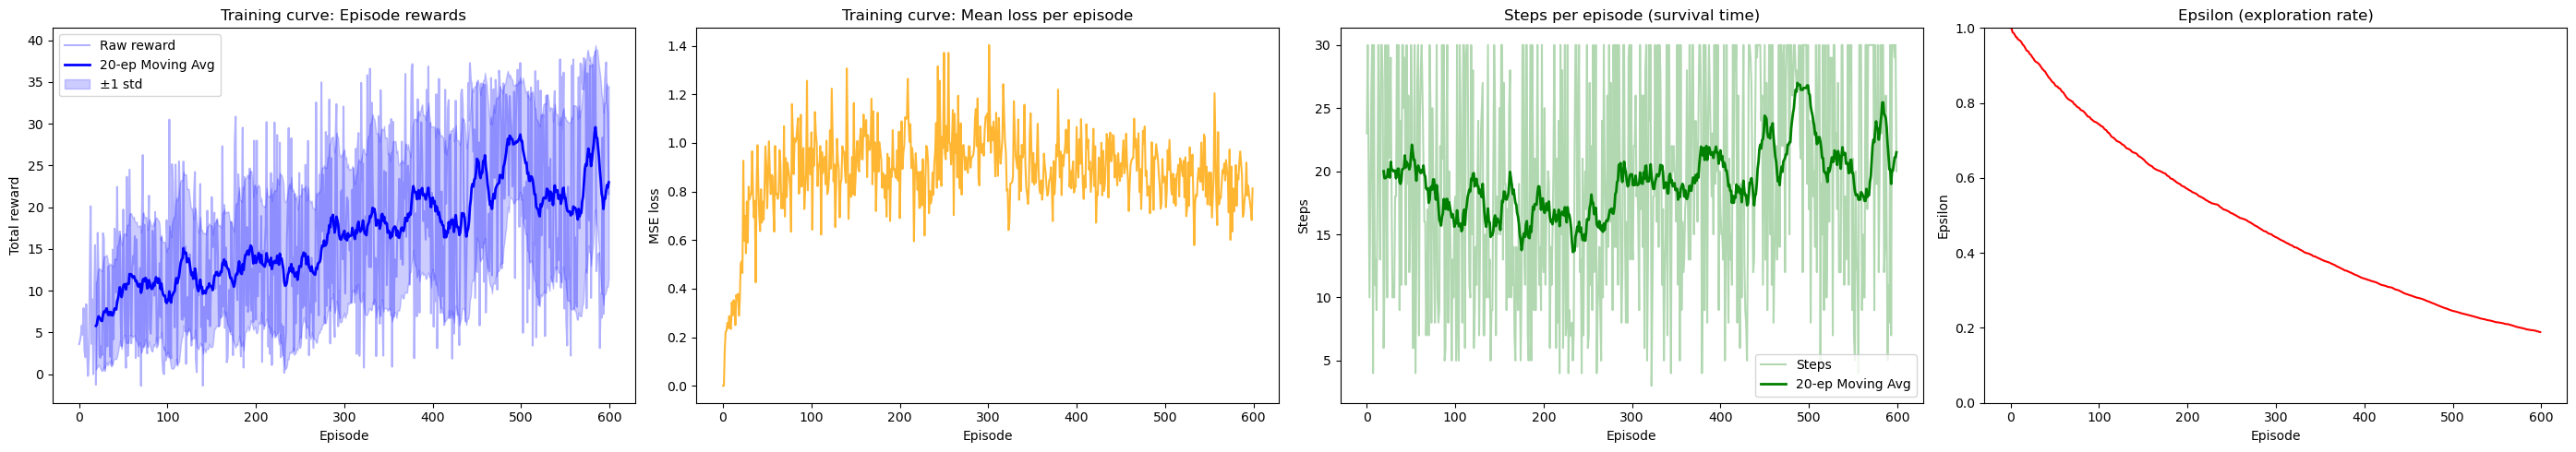

In [20]:
plot_training_curves(dqn_rewards, dqn_losses, dqn_lengths, dqn_epsilons)

In [21]:
dqn_results = evaluate_agent(trained_dqn_agent, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [05:07<00:00,  6.16s/it]



Seed 3 — 50 episodes
  Reward     :   9.57 ± 6.41  [min: 0.99, max: 29.94]
  Steps      :   10.8 ± 6.4  [min: 2, max: 30]
  Crashes    : 49/50 (98.0% crash rate, 2.0% survival)
  Mean speed : 27.75 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :   2.3 steps
    IDLE        :   4.4 steps
    LANE_RIGHT  :   3.1 steps
    FASTER      :   1.0 steps
    SLOWER      :   0.0 steps



Evaluating Seed 333: 100%|██████████| 50/50 [05:06<00:00,  6.13s/it]



Seed 333 — 50 episodes
  Reward     :   9.68 ± 7.24  [min: 0.97, max: 29.95]
  Steps      :   10.9 ± 7.3  [min: 2, max: 30]
  Crashes    : 49/50 (98.0% crash rate, 2.0% survival)
  Mean speed : 27.65 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :   2.7 steps
    IDLE        :   4.1 steps
    LANE_RIGHT  :   3.1 steps
    FASTER      :   1.1 steps
    SLOWER      :   0.0 steps



Evaluating Seed 3333:  24%|██▍       | 12/50 [00:56<02:59,  4.72s/it]


KeyboardInterrupt: 

## 2e entraînement

In [ ]:
file_path = "./models/agressive_ddqn_highway.pth"

N_EPISODES = 800

env2 = make_env()

agent_phase2 = HighwayDQN(
    env=env2,
    gamma=0.8,    # Idéal pour cet environnement (survie à court/moyen terme)
    batch_size=32,
    buffer_capacity=15000,
    update_target_every=50,
    epsilon_start=0.30,            # On commence à 30% d'exploration 
    decrease_epsilon_factor=6000,  
    epsilon_min=0.05,
    learning_rate=5e-4,
    model_type="DDQN"             
)

agent_phase2.load(file_path)


N_EPISODES_PHASE_2 = 800
print("Début de l'entraînement Phase 2 (Trafic dense)")

trained_agent_phase2, rewards2, losses2, lengths2, epsilons2 = train_agent(
    agent_phase2, 
    env2, 
    n_episodes=N_EPISODES_PHASE_2
)


final_file_path = "./models/agressive_ddqn_highway_FINAL.pth"
trained_agent_phase2.save(final_file_path) 
print(f"Modèle final sauvegardé sous : {final_file_path}")

Initializing DQN on device: cpu
Début de l'entraînement Phase 2 (Trafic dense)


Training agent:   2%|▏         | 16/800 [01:28<1:12:30,  5.55s/it]


KeyboardInterrupt: 

In [ ]:
plot_training_curves(rewards2, losses2, lengths2, epsilons2)

In [ ]:
dqn_results = evaluate_agent(trained_agent_phase2, num_episodes=50)